# Parameters configuration
import openseespy.opensees as ops  # Import OpenSeesPy for structural analysis
import opsvis as opsv  # Import opsvis for visualization
import matplotlib.pyplot as plt  # Import Matplotlib for plotting
ops.wipe()  # Clear any existing model
ops.model('basic', '-ndm', 2, '-ndf', 3)  # Define a 2D model with 3 degrees of freedom per node (DOF)
# Column and girder lengths and roof height
colH, colSpacing, roofH = 4.0, 8.0, 3.0
# Section properties: cross-sectional area (A) and moment of inertia (Iz)
Acol, Adiag = 2.e-3, 6.e-3
IzCol, IzDiag = 1.6e-5, 5.4e-5
# Young's modulus (E)
E = 200.e9
# Point Load
P_load = 2.e3
# Define the material property dictionary for columns and girders
Ep = {
    1: [2e11, 2e-3, 1.6e-5],  # Column element 1
    2: [2e11, 2e-3, 1.6e-5],  # Column element 2
    3: [2e11, 6e-3, 5.4e-5],  # Diagonal element 3
    4: [2e11, 6e-3, 5.4e-5]   # Diagonal element 4
}

# Define the node coordinates
ops.node(1, 0, 0)          # Node 1 (bottom lef

Current Domain Information
	Current Time: 1
	Committed Time: 1
NODE DATA: NumNodes: 5

numComponents: 5

 Node: 1
	Coordinates  : 0 0 
	Disps: 0 0 0 
	 unbalanced Load: 0 0 0 
	ID : -1 -1 -1 


 Node: 2
	Coordinates  : 0 4 
	Disps: 0.00259578 4.44827e-06 -0.000177053 
	 unbalanced Load: 2000 0 0 
	ID : 6 7 8 


 Node: 3
	Coordinates  : 8 0 
	Disps: 0 0 0 
	 unbalanced Load: 0 0 0 
	ID : -1 -1 -1 


 Node: 4
	Coordinates  : 8 4 
	Disps: 0.001841 -4.44827e-06 -0.000374674 
	 unbalanced Load: 0 0 0 
	ID : 0 1 2 


 Node: 5
	Coordinates  : 4 7 
	Disps: 0.00222312 0.000499548 0.000136013 
	 unbalanced Load: 0 0 0 
	ID : 3 4 5 

ELEMENT DATA: NumEle: 4

numComponents: 4

ElasticBeam2d: 1
	Connected Nodes: 1 2 
	CoordTransf: 1
	mass density:  0, cMass: 0
	release code:  0
	End 1 Forces (P V M): -444.827 1345.01 2831.66
	End 2 Forces (P V M): 444.827 -1345.01 2548.37

ElasticBeam2d: 2
	Connected Nodes: 3 4 
	CoordTransf: 1
	mass density:  0, cMass: 0
	release code:  0
	End 1 Forces (P V M): 44

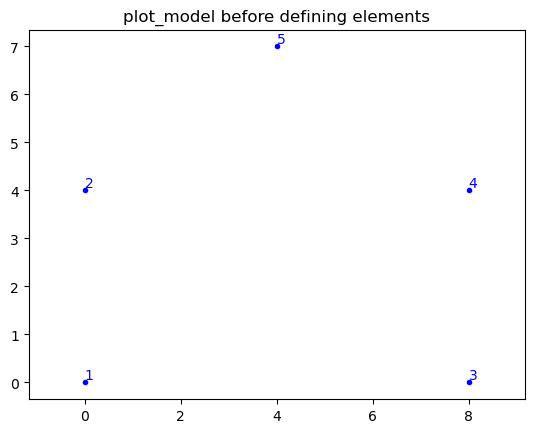

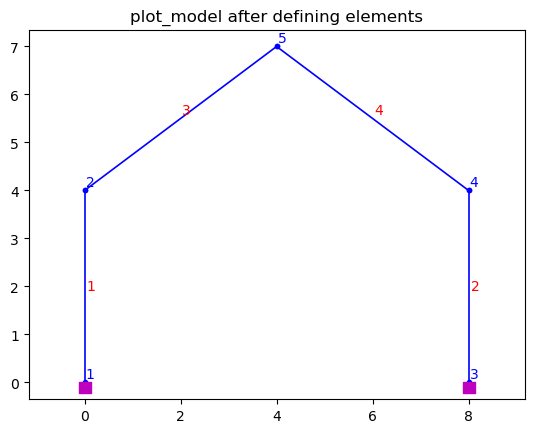

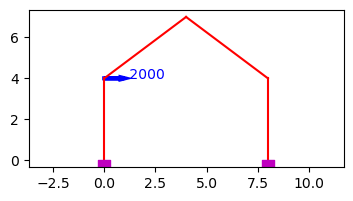

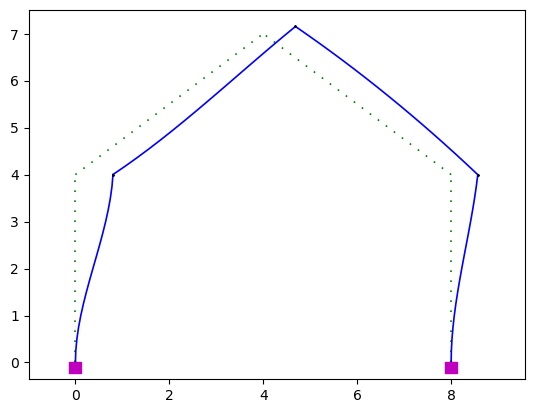

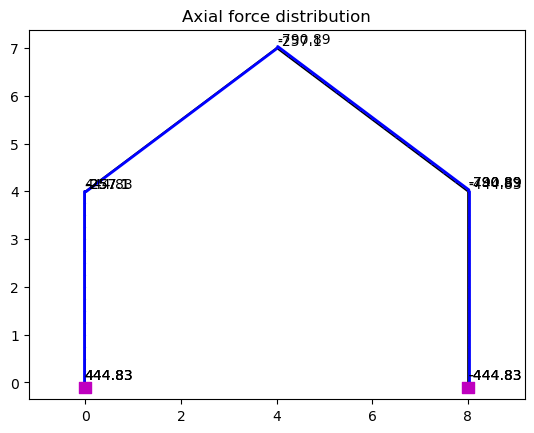

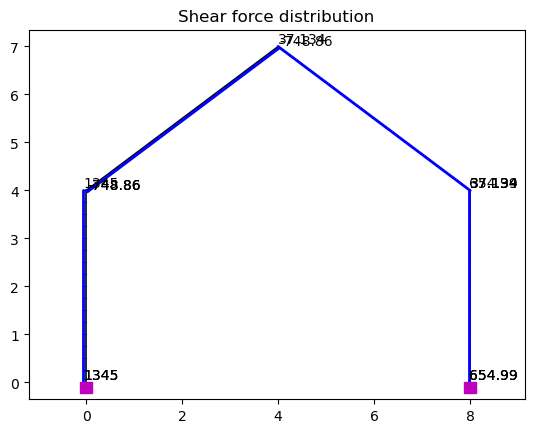

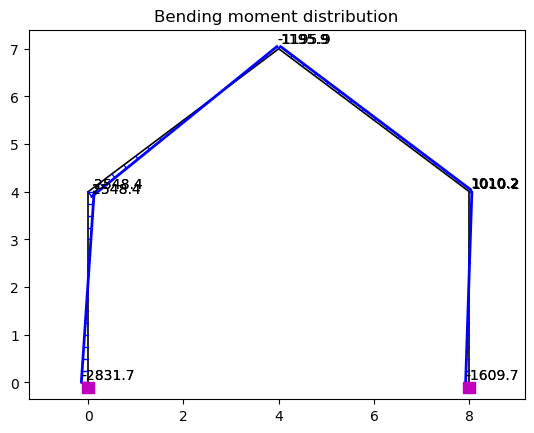

NameError: name 'exit' is not defined

In [24]:
import openai
import os
import runpy
from database_utils import fetch_merged_text
from database_utils import fetch_ICL

def test_gpt_api():
    # Set your API key
    openai.api_key = ""

    # Database file path
    db_path_ICL = r"C:\Users\liang\Desktop\RA\python\gpt_4o_v2\ICL.db"
    db_path_request = r"C:\Users\liang\Desktop\RA\python\gpt_4o_v2\request.db"
    # Test Example Number
    ICL_num=1
    test_num=15

    user_message = fetch_merged_text(db_path_request, test_num, 1)

    response = openai.ChatCompletion.create(
        model="gpt-4o-2024-11-20",
        messages=[
            {"role": "user", "content": user_message}
        ]
    )


    # Print the content returned by the API
    print(response.choices[0].message["content"])

    # Save the generated code into a py file
    generated_code = response.choices[0].message["content"]
    with open("param_config.py", "w", encoding="utf-8") as code_file:
        code_file.write(generated_code)

    # Read background information and request content from a db file
    background_info = fetch_ICL(db_path_ICL, ICL_num)
    user_message = fetch_merged_text(db_path_request, test_num, 2)

    # Build a request with background information
    response = openai.ChatCompletion.create(
        model="gpt-4o-2024-11-20",
        messages=[
            {"role": "system", "content": background_info},
            {"role": "user", "content": user_message}
        ]
    )

    # Print the content returned by the API
    print(response.choices[0].message["content"])

    # Save the generated code into a py file
    generated_code = response.choices[0].message["content"]
    with open("main.py", "w", encoding="utf-8") as code_file:
        code_file.write(generated_code)


    user_message = fetch_merged_text(db_path_request, test_num, 3)

    # Build a request with background information
    response = openai.ChatCompletion.create(
        model="gpt-4o-2024-11-20",
        messages=[
            {"role": "user", "content": user_message}
        ]
    )

    # Print the content returned by the API
    print(response.choices[0].message["content"])

    # Save the generated code into a py file
    generated_code = response.choices[0].message["content"]
    with open("post_proc.py", "w", encoding="utf-8") as code_file:
        code_file.write(generated_code)

# Set file names
a_filename = 'param_config.py'
b_filename = 'main.py'
c_filename = 'post_proc.py'
d_filename = 'full_program.py'
def merge_files(a_file, b_file, c_file, d_file):
    try:
        # Open A, B, C files, and read their content
        with open(a_file, 'r') as file_a:
            content_a = file_a.read()
        with open(b_file, 'r') as file_b:
            content_b = file_b.read()
        with open(c_file, 'r') as file_c:
            content_c = file_c.read()

        # Open D file and write content
        with open(d_file, 'w') as file_d:
            file_d.write(content_a)  # Write content of file A
            file_d.write('\n')
            file_d.write(content_b)  # Write content of file B
            file_d.write('\n')
            file_d.write(content_c)  # Write content of file C

        print(f"Successfully merged {a_file}, {b_file}, {c_file} into {d_file}")
    except Exception as e:
        print(f"Error occurred during merging: {e}")

if __name__ == "__main__":
    test_gpt_api()
    merge_files(a_filename, b_filename, c_filename, d_filename)


# Run full_program.py
if os.system(f"python {d_filename}") != 0:
    print(f"Error occurred while running {d_filename}")

%run full_program.py